In [30]:
import pandas as pd

df = pd.read_csv('D:\\co22.csv')
df.head(5)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [32]:
encoding_columns = ['Make','Model','Vehicle Class','Transmission','Fuel Type']

In [33]:
enc_classes = {} 
def encoding_label(x):   # x: 범주형 타입의 컬럼(Series)
    le = LabelEncoder()
    le.fit(x)
    label = le.transform(x)
    enc_classes[x.name] = le.classes_   # x.name: 컬럼명
    return label

In [37]:
d1 = df.apply(encoding_label)
d1.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,0,1057,0,8,1,14,4,56,25,43,22,86
1,0,1057,0,12,1,25,4,69,35,54,18,111
2,0,1058,0,5,1,22,4,17,16,17,37,29
3,0,1233,11,21,3,15,4,84,49,69,14,145
4,0,1499,11,21,3,15,4,78,45,64,16,134


C:\Users\Jeongmin\AppData\Local\Temp\ipykernel_117124\557249295.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  style.use('seaborn-whitegrid')
C:\Users\Jeongmin\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


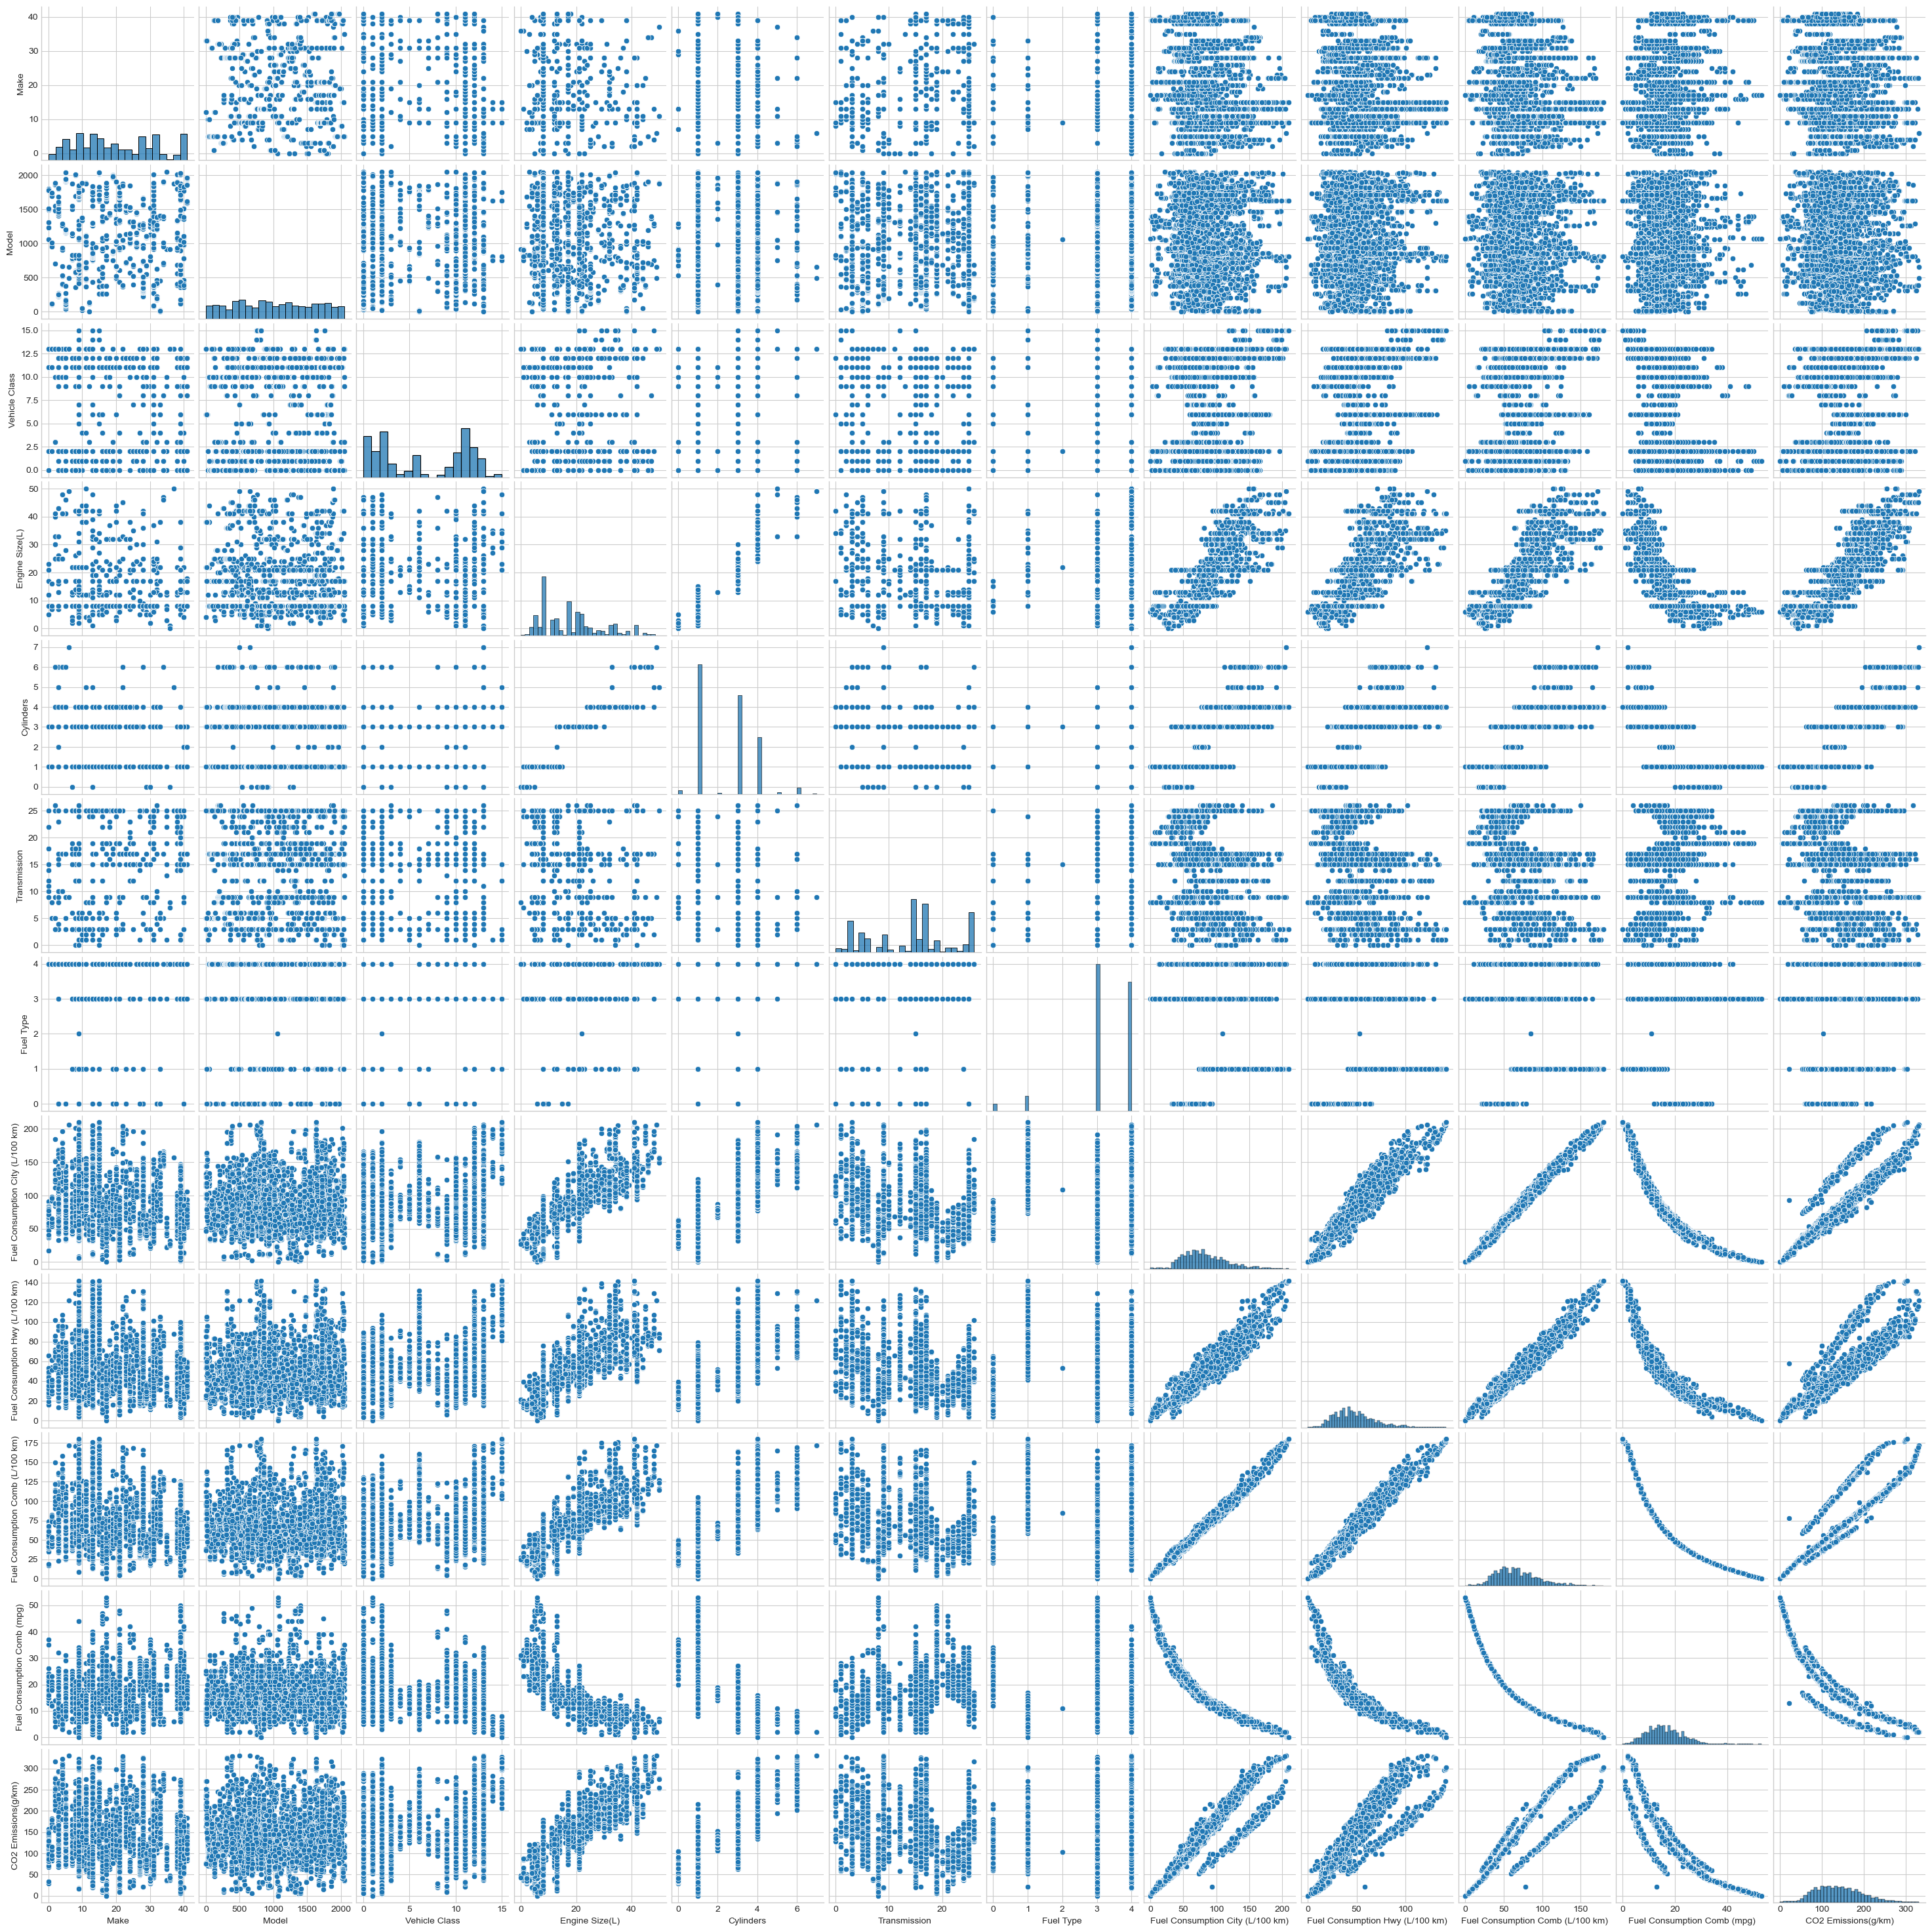

In [39]:
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import style

style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (20,10)

sb.pairplot(d1)
plt.savefig('pairplor.png')

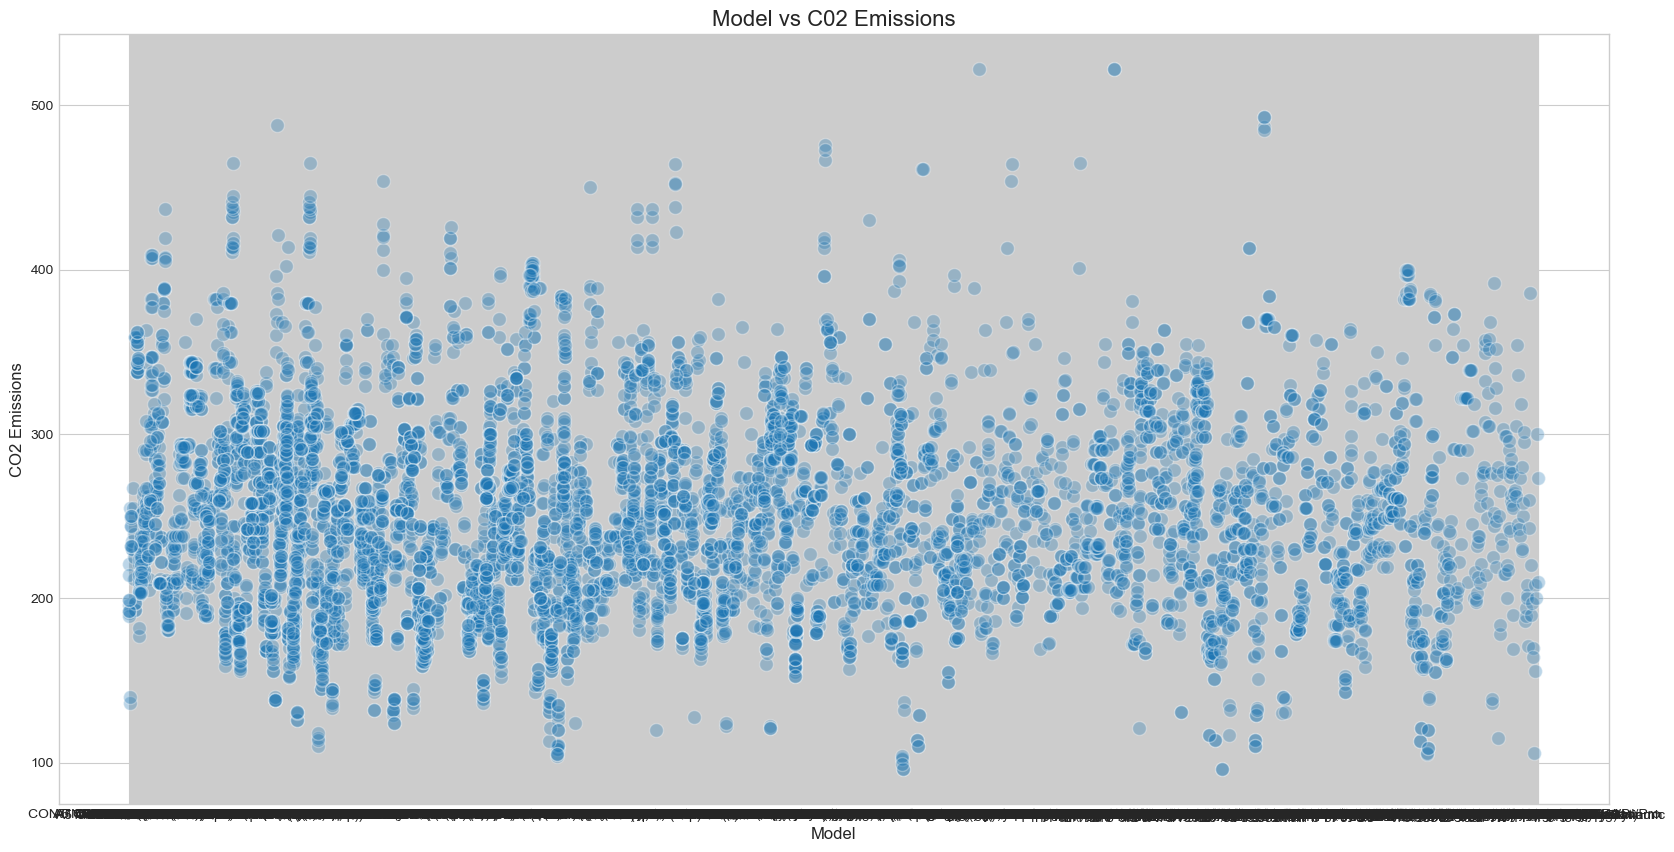

In [60]:
plt.scatter(x = 'Model', y = 'CO2 Emissions(g/km)', data = df, s = 100, alpha = 0.3, edgecolor = 'white')

plt.title('Model vs C02 Emissions', fontsize = 16)
plt.ylabel('CO2 Emissions', fontsize = 12)
plt.xlabel('Model', fontsize = 12)

plt.savefig('enginesize_co2.png')

In [64]:
from sklearn.model_selection import train_test_split

X_var = df[['Model']] # independent variable
y_var = df['CO2 Emissions(g/km)'] # dependent variable

X_train, X_test, y_train, y_test = train_test_split(X_var, y_var, test_size = 0.3, random_state = 0)

In [65]:
from sklearn.linear_model import LinearRegression
    
lr = LinearRegression()
lr.fit(X_train, y_train)
yhat = lr.predict(X_test)

ValueError: could not convert string to float: 'E 250 BLUETEC 4MATIC'

In [58]:
from termcolor import colored as cl

print(cl('R-Squared :', attrs = ['bold']), lr.score(X_test, y_test))

ValueError: could not convert string to float: 'PORSCHE'

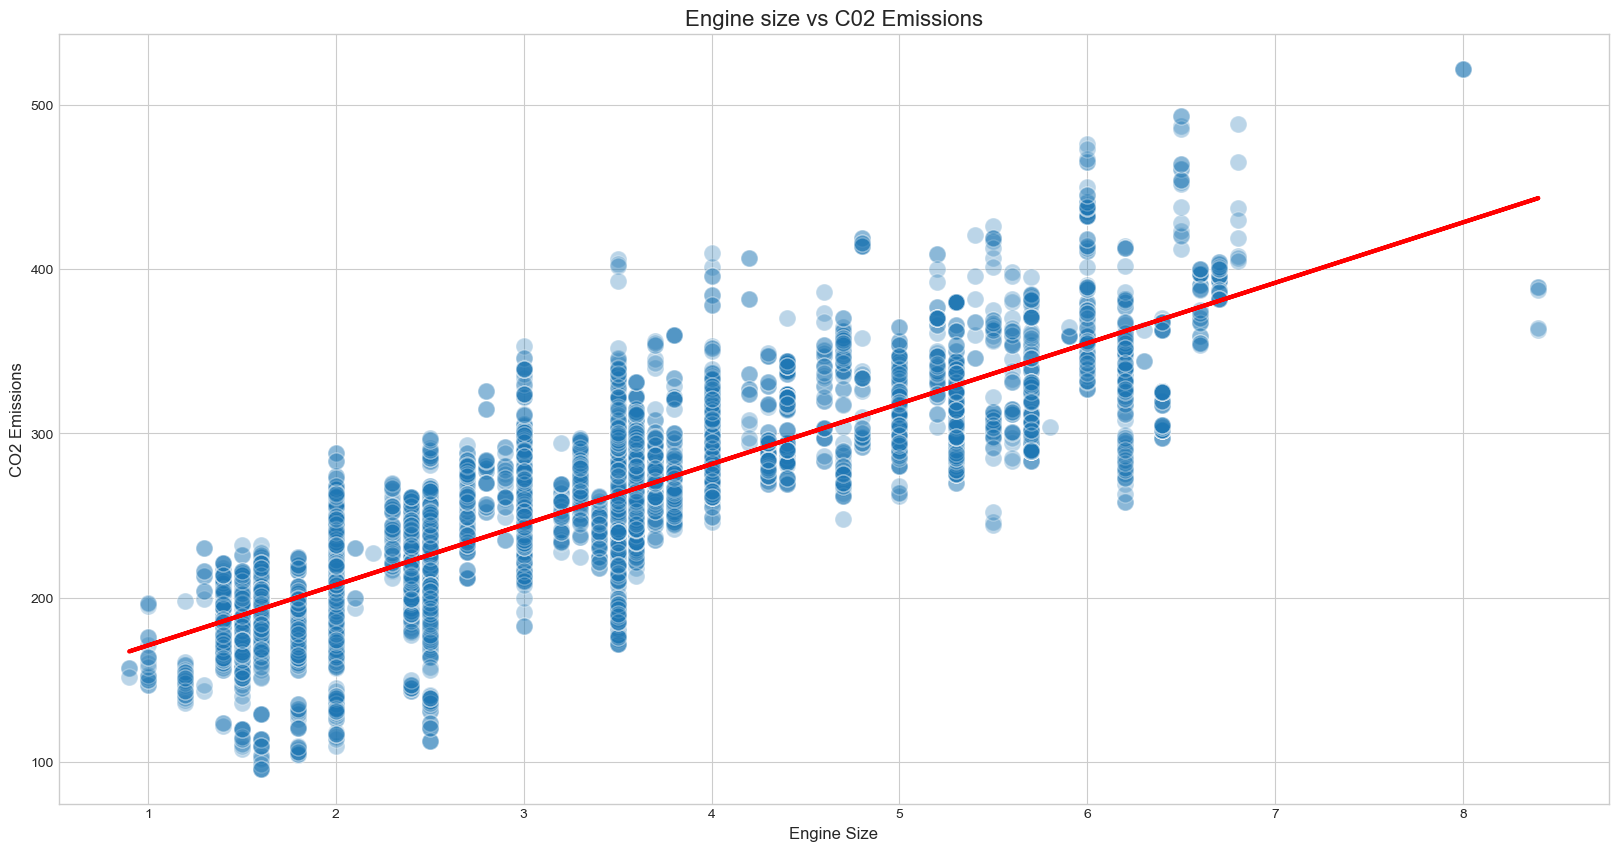

In [44]:
slr_slope= lr.coef_
slr_intercept= lr.intercept_

sb.scatterplot(x = 'Engine Size(L)', y = 'CO2 Emissions(g/km)', data = df, s = 150, alpha = 0.3, edgecolor= 'white')

plt.plot(df['Engine Size(L)'], slr_slope*df['Engine Size(L)'] + slr_intercept, color = 'r', linewidth = 3)

plt.title('Engine size vs C02 Emissions', fontsize= 16)
plt.ylabel('CO2 Emissions', fontsize= 12)
plt.xlabel('Engine Size', fontsize= 12)

plt.savefig('enginesize_co2_fit.png')

In [45]:
from sklearn.model_selection import train_test_split

X1_var = df[['Engine Size(L)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption City (L/100 km)']]
y_var= df['CO2 Emissions(g/km)'] # dependent variable

X_train, X_test, y_train, y_test= train_test_split( X1_var, y_var, test_size= 0.3, random_state= 0)

In [46]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)
yhat = lr.predict(X_test)

In [47]:
from termcolor import colored as cl

print(cl('R-Squared :', attrs=['bold']), lr.score(X_test,y_test))

R-Squared : 0.8655946234480003


C:\Users\Jeongmin\AppData\Local\Temp\ipykernel_117124\2045882254.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(yhat,hist=False,color='r',label='Prediced Values')
C:\Users\Jeongmin\AppData\Local\Temp\ipykernel_117124\2045882254.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.dist

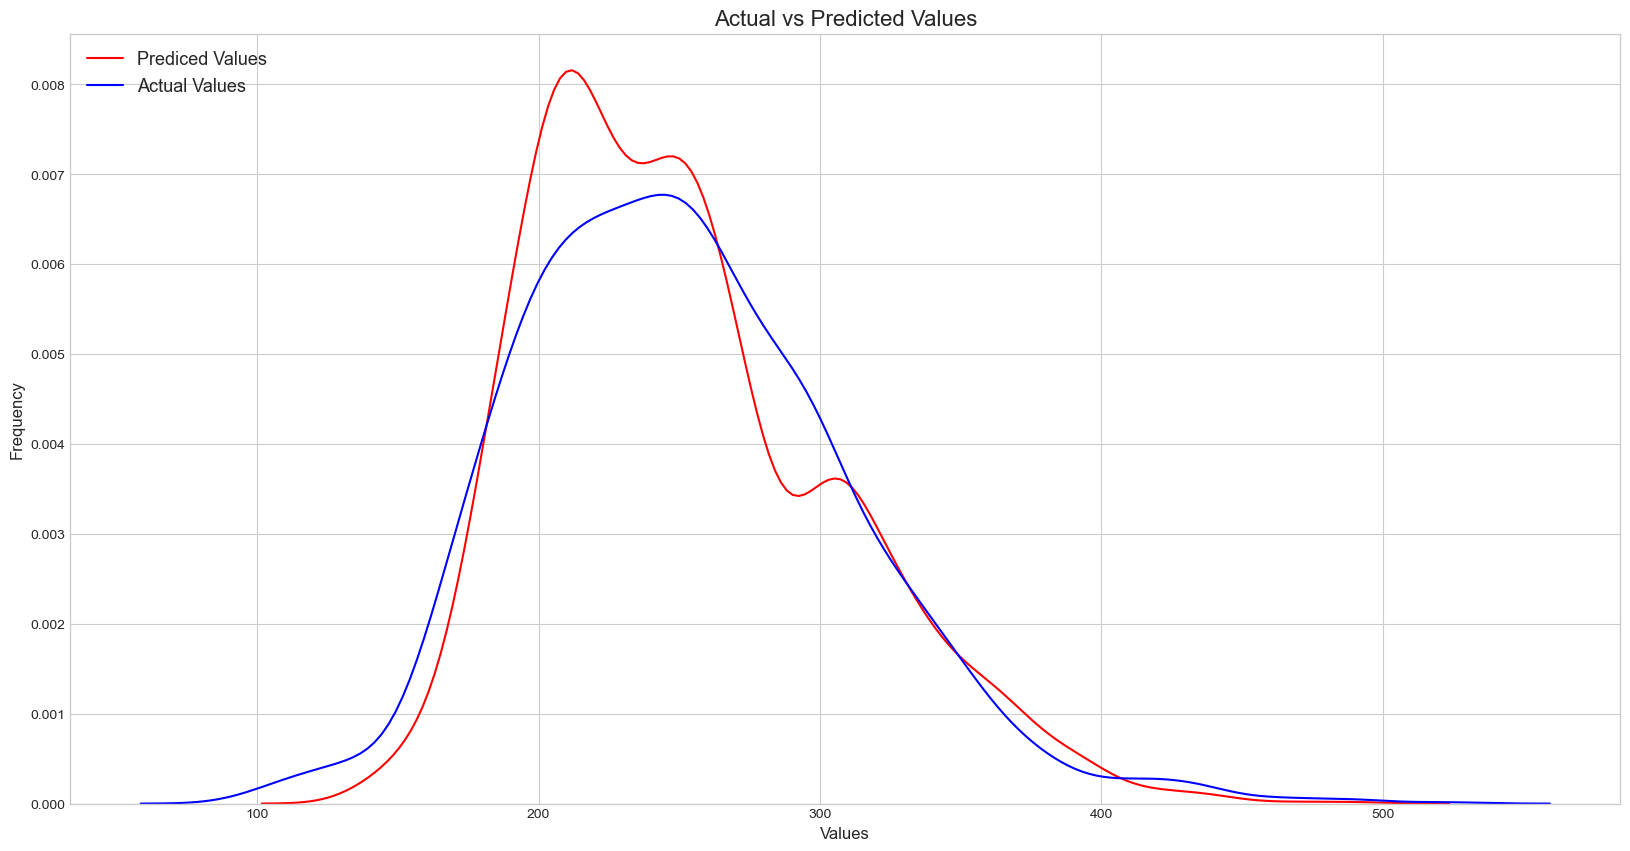

In [48]:
sb.distplot(yhat,hist=False,color='r',label='Prediced Values')
sb.distplot(y_test, hist=False, color='b',label='Actual Values')
plt.title('Actual vs Predicted Values',fontsize=16)
plt.xlabel('Values', fontsize = 12)
plt.ylabel('Frequency', fontsize = 12)
plt.legend(loc = 'upper left', fontsize = 13)

plt.savefig('ap.png')